###  STROKE DETECTION / PREDICTION MODELLING 
#### INTRODUCTION

Stroke is a medical emergency that occurs when blood flow to the brain is interrupted, either due to a blockage or bleeding. This lack of blood flow can lead to brain cell death and serious complications. Strokes can be fatal and need immediate treatment.

According to the World Health Organization, there were about 11.9 million new cases of stroke in 2021. This spiked the total number of stroke cases worldwide to about 93.8 million cases globally, making it the third leading cause of death and disability. Presently, it is considered to be the second leading cause of death worldwide.

There are modifiable and non-modifiable risk factors for stroke. Some modifiable risk factors are hypertension, tobacco use, high blood cholesterol, diabetes mellitus, high levels of low-density lipoprotein cholesterol, overweight and obesity, physical inactivity, unhealthy diet, harmful use of alcohol, use of illicit drugs (e.g., cocaine), air pollution, high fasting blood glucose, and kidney dysfunction.

some non-modifiable risk factors are age, prior stroke, pre-existing cardiac conditions (e.g., atrial fibrillation, heart failure) and chronic kidney disease.

According to major health associations, **about 80% of death and disability due to stroke are preventable.**

The key to minimizing the damage caused by a stroke lies in the time it takes to detect and receive treatment. Brain cells die at an alarming rate during a stroke, and the longer the delay, the greater the loss of brain function. The mantra often repeated in stroke awareness is “Time is brain,” meaning every minute lost can translate to the loss of brain cells and critical functions. 

The purpose of this project is to create a model that predicts the occurrence of stroke or otherwise for an individual considering some other known medical and lifestyle information.

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
#scikit-learn library
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, f1_score, precision_score, r2_score,roc_auc_score, average_precision_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, roc_curve

sns.set_theme(style="darkgrid")

import warnings
warnings.filterwarnings("ignore")



In [2]:
#Loading dataset into dataframe
stroke_dset = pd.read_csv(r"C:\Users\abdul\Downloads\healthcare-dataset-stroke-data.csv")

stroke_dset

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [3]:
#checking the size of the dataset
stroke_dset.shape

(5110, 12)

In [4]:
#Having an initial inspection of the dataset
stroke_dset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
#checking for duplicated values

stroke_dset.duplicated().sum()

np.int64(0)

In [6]:
#checking the sum of the missing values in each column
stroke_dset.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
#checking the percentage of the missing values in each column

missing_percentage =((stroke_dset.isnull().sum()/len(stroke_dset))*100).sort_values(ascending=False)
missing_percentage

bmi                  3.933464
id                   0.000000
age                  0.000000
gender               0.000000
hypertension         0.000000
heart_disease        0.000000
work_type            0.000000
ever_married         0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
smoking_status       0.000000
stroke               0.000000
dtype: float64

In [8]:
stroke_dset["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [9]:
stroke_dset["Residence_type"].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [10]:
stroke_dset["ever_married"].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

In [11]:
stroke_dset["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [12]:
stroke_dset["work_type"].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [13]:
stroke_dset["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

From the exploration above, we can see that the Residence type, Marital status, Smoking status and even work type have reasonable amount of data in the categories(/values) under them. Unlike the previous gender data, there will be no need to drop any row.

However, the stroke column shows us an imbalance. There are more people with stroke than without stroke despite important factors like residence type that greatly contributes to the cardiac health of residents, work type and even smoking status. Althought this will be addressed in the model building and fine tuning.

Now, let's visualise the dataset

#### Observations on Dataset

- There are 5110 rows and 12 columns originally on the dataset.
- Dataset contains null BMI values (201). To ensure realistic BMI information, the null values will be filled with the median of the BMI values by age.
- There are no duplications in the dataset.
- Medically, there are only two sexes (gender). There is a record with “other” value as gender. Since this may result in a huge variation and we have only one value with the gender as"other", it is necessary we drop the column so as not to introduce any form of noise to our model.
- The unknown category in the "smoking status" may reflect situations where information is missing, unreliable, or unavailable. children may also fall into this category. To maintain data integrity and given the number of  records involved, it will be maintained as a category.
- The “age” column is a float and should be converted to integer.

## 1. Data Cleaning

In [14]:
#changing the Age column from float to integer
stroke_dset['age'] = stroke_dset['age'].astype('int')

In [15]:
stroke_dset['age'].dtypes

dtype('int64')

In [16]:
stroke_dset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int64  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 479.2+ KB


In [17]:
# Filling the missing values in Bmi with median (by ages of each record)
stroke_dset['bmi'] = stroke_dset['bmi'].fillna(stroke_dset.groupby("age")['bmi'].transform("median"))

In [18]:
filtered_gender = stroke_dset[stroke_dset["gender"] == "Other"]
filtered_gender

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
3116,56156,Other,26,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0


In [19]:
#droping the record with "Other" under "gender" column
stroke_dset.drop(index=3116, inplace=True)

In [20]:
stroke_dset["gender"].value_counts()

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [21]:
stroke_dset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5109 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5109 non-null   int64  
 1   gender             5109 non-null   object 
 2   age                5109 non-null   int64  
 3   hypertension       5109 non-null   int64  
 4   heart_disease      5109 non-null   int64  
 5   ever_married       5109 non-null   object 
 6   work_type          5109 non-null   object 
 7   Residence_type     5109 non-null   object 
 8   avg_glucose_level  5109 non-null   float64
 9   bmi                5109 non-null   float64
 10  smoking_status     5109 non-null   object 
 11  stroke             5109 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 518.9+ KB


## 2. Exploratory Data Analysis

### Univariate 

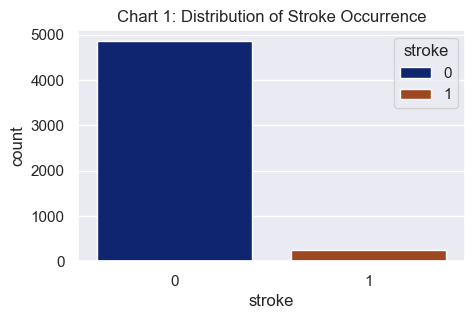

In [22]:
# a.Univariate analysis (Check for class imbalance in dependent variable)

plt.figure(figsize=(5, 3))
sns.countplot(x="stroke", data=stroke_dset, hue="stroke", palette="dark")
plt.title("Chart 1: Distribution of Stroke Occurrence")
plt.savefig("stroke_distribution.png")

plt.show()

In [23]:
stroke_ir_ratio = stroke_dset["stroke"].value_counts()[0] / stroke_dset["stroke"].value_counts()[1]

print(f'The Imbalance Ratio (IR) for the stroke occurence variable is {stroke_ir_ratio:.2f}')

The Imbalance Ratio (IR) for the stroke occurence variable is 19.52


In [24]:
# selecting three numeric columns
#selected the Age, Avg Glucose Level, and BMI columns for outlier checking because the other numeric variables are binary

selected_numeric_columns = stroke_dset[['age','avg_glucose_level','bmi']]
selected_numeric_columns
                           

,age,avg_glucose_level,bmi
0,67,228.69,36.60
1,61,202.21,29.45
2,80,105.92,32.50
3,49,171.23,34.40
4,79,174.12,24.00
...,...,...,...
5105,80,83.75,28.70
5106,81,125.20,40.00
5107,35,82.99,30.60
5108,51,166.29,25.60


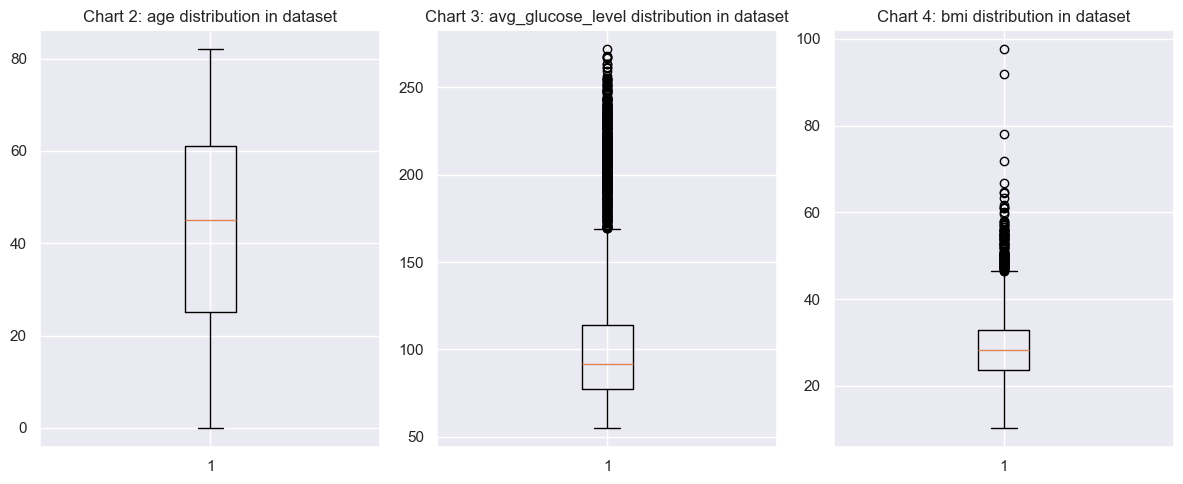

In [25]:
# Plotting a boxplot to viuslaize the distribution of numerical features in dataset
plt.figure(figsize=(12,5))

for i, column in enumerate(selected_numeric_columns.columns, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(selected_numeric_columns[column])
    plt.title(f"Chart {i+1}: {column} distribution in dataset")

plt.tight_layout()
plt.show()

#### Further analysis on the numerical features

In [26]:
# Age range for the datset
age_range = (stroke_dset["age"].max() - stroke_dset["age"].min())


print(f'The number of respondents less than a year old is {(stroke_dset["age"].value_counts()[0])}')
print(f"The maximum age recorder is {stroke_dset["age"].max()} while the minimum age recorded is {stroke_dset["age"].min()}.\n The range of ages in dataset is {age_range}")

#Maximum, Minimum and range of bmi in dataset
bmi_range = stroke_dset["bmi"].max() - stroke_dset["bmi"].min()


print(f"\nThe maximum bmi recorder is {stroke_dset["bmi"].max()} while the minimum bmi recorded is {stroke_dset["bmi"].min()}.\nThe range of bmi in dataset is {bmi_range}") 

# Maximum, Minimum and range of average glucose level in dataset
avl_range = stroke_dset["avg_glucose_level"].max() - stroke_dset["avg_glucose_level"].min()


print(f"\nThe average glucose level ranges from the maximum average glucose level of {stroke_dset["avg_glucose_level"].max()} and minimum level of {stroke_dset["avg_glucose_level"].min()}.") 

The number of respondents less than a year old is 43
The maximum age recorder is 82 while the minimum age recorded is 0.
 The range of ages in dataset is 82

The maximum bmi recorder is 97.6 while the minimum bmi recorded is 10.3.
The range of bmi in dataset is 87.3

The average glucose level ranges from the maximum average glucose level of 271.74 and minimum level of 55.12.


In [27]:
#outliers - Extreme high Average Glucose Level (Diabetics) 
agl_Q1 = stroke_dset["avg_glucose_level"].quantile(0.25)
agl_Q3 = stroke_dset["avg_glucose_level"].quantile(0.75)
agl_IQR = agl_Q3 - agl_Q1
agl_upper_whisker = (1.5 * agl_IQR) + agl_Q3
agl_outliers = len(stroke_dset["avg_glucose_level"][stroke_dset["avg_glucose_level"]>=agl_upper_whisker])

print(f"average glucose level values are concentrated between {agl_Q1} and {agl_Q3}. There are {agl_outliers} cases of very high glucose level recorded with average glucose level greater than {agl_upper_whisker:.2f}")

#outliers - Super Obesity
bmi_Q1 = stroke_dset["bmi"].quantile(0.25)
bmi_Q3 = stroke_dset["bmi"].quantile(0.75)
bmi_IQR = bmi_Q3 - bmi_Q1
bmi_upper_whisker = (1.5 * bmi_IQR) + bmi_Q3
super_obese = len(stroke_dset["bmi"][stroke_dset["bmi"]>=bmi_upper_whisker])

print(f"bmi values are concentrated between {bmi_Q1} and {bmi_Q3}. There are {super_obese} cases of super obesity recorded with bmi greater than {bmi_upper_whisker:.2f}")

average glucose level values are concentrated between 77.24 and 114.09. There are 627 cases of very high glucose level recorded with average glucose level greater than 169.37
bmi values are concentrated between 23.7 and 32.8. There are 123 cases of super obesity recorded with bmi greater than 46.45


In [28]:
stroke_dset.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000,5109.000000
mean,36513.985516,43.218634,0.097475,0.054022,106.140399,28.883157,0.048738
std,21162.008804,22.634799,0.296633,0.226084,45.285004,7.725473,0.215340
min,67.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17740.000000,25.000000,0.000000,0.000000,77.240000,23.700000,0.000000
50%,36922.000000,45.000000,0.000000,0.000000,91.880000,28.200000,0.000000
75%,54643.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### Univariate - Categorical Features 

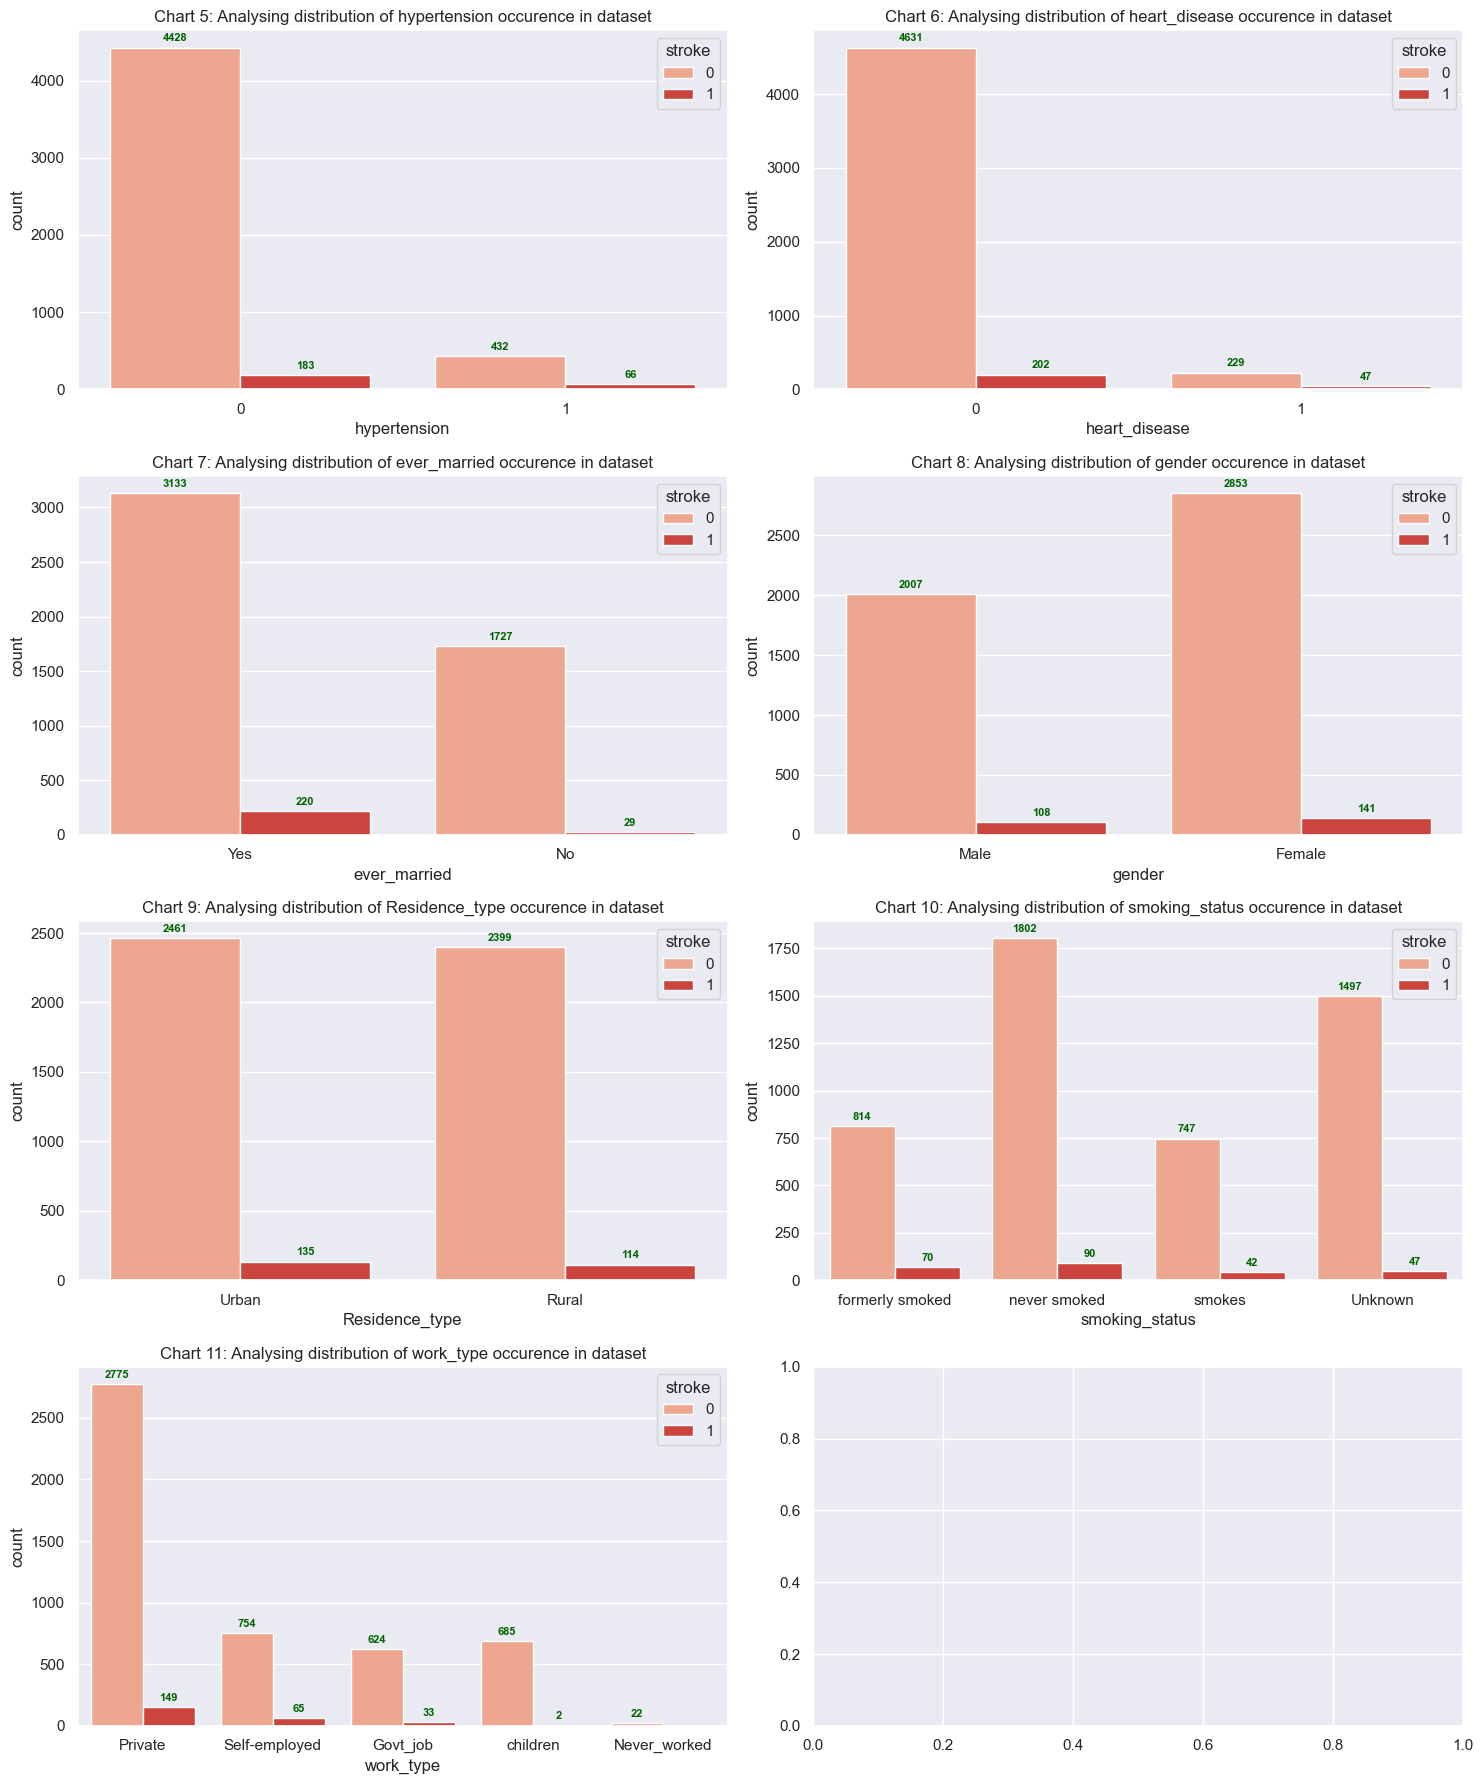

In [29]:
#create a list of categorical features
cat_features = ["hypertension", "heart_disease", "ever_married", "gender", "Residence_type", "smoking_status", "work_type"]
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten() 
for i, cat in enumerate(cat_features):
    bars= sns.countplot(data = stroke_dset, x=cat, palette= "Reds", hue="stroke",  legend=True, ax=axes[i])
    for j in bars.containers:
        axes[i].bar_label(j, padding=3, color="darkgreen",fontweight="bold", fontsize= 8)
        #bars.bar_label(j, padding=3, color="darkgreen",fontweight="bold", fontsize= 8)
        #sns.countplot(ax=axes[i], x=cat, hue=cat, data=stroke_dset, palette="dark")
    axes[i].set_title(f"Chart {i+5}: Analysing distribution of {cat} occurence in dataset")
  
plt.tight_layout()

plt.show()

#### UNIVARIATE ANALYSIS

From Chart 1 above, the boxplot visualizes the extent of class imbalance that occurs in the dependent variable (Stroke/No stroke occurrence). The chart shows that the data is skewed towards the negative class (No stroke - 0). The Imbalance Ratio (IR), which is the ratio of the majority class to the minority class, is **19.52**. The minority class (stroke - 1) therefore occupies just above 5% of the total items in the column. 

Class imbalance does pose a challenge during classification modelling as bias seems to always be in favour of the majority class. It must therefore be ensured that not only is a good model with a record of good performance with class imbalance cases selected during prediction, but also that necessary tuning is applied to the selected training model.

The ages of the respondents range between 0 and 82 years. The boxplot in Chart 1 shows that the respondent’s ages are concentrated between about 25 and 62 years old. It also shows that there are no outliers. There are 43 respondents with ages less than 1. This case is valid as neonatal stroke can occur in newborns (1 in 2500 - 4000 newborns). Heart defect is also one of the risk factors for this type of stroke.

The body mass index recorded in the dataset ranges between a maximum of 97.6 and a minimum of 10.3. The boxplot in Chart 2 shows that the BMI values are concentrated between 23.7 and 32.8. There are however 123 cases of super obesity recorded with BMI greater than 46.45. having extremely high BMI values are medically possible and are known risk factors for stroke. Therefore, these values may represent genuine clinical cases rather than data entry errors

Average glucose levels are best determined over 2–3 months using the HbA1C blood test (or A1C), which measures glucose attached to hemoglobin. The result indicates diabetic occurrence or otherwise. In the dataset, average glucose level is concentrated between 77.24 and 114.09 mg/dL. The chart also indicates outliers with values greater than 169.37 mg/dL.

The group of charts above (charts 5 - 11) visualize the distribution of other categorical features in the dataset. The countplot for hypertension and heart diseases shows a similar imbalance with that of the stroke occurrence with the data skewed greatly towards the negative class.
The distribution of hypertension in the dataset shows that the majority of individuals 4612, about 90% do not have hypertension, while only 498 individuals (about 10%) are hypertensive. Although the proportion of hypertensive individuals is relatively small, hypertension is a well-established clinical risk factor for stroke. This suggests that even a smaller group of hypertensive patients may contribute significantly to stroke occurrence, making hypertension an important variable to consider in predictive modeling.

### BIVARIATE ANALYSIS

<function matplotlib.pyplot.show(close=None, block=None)>

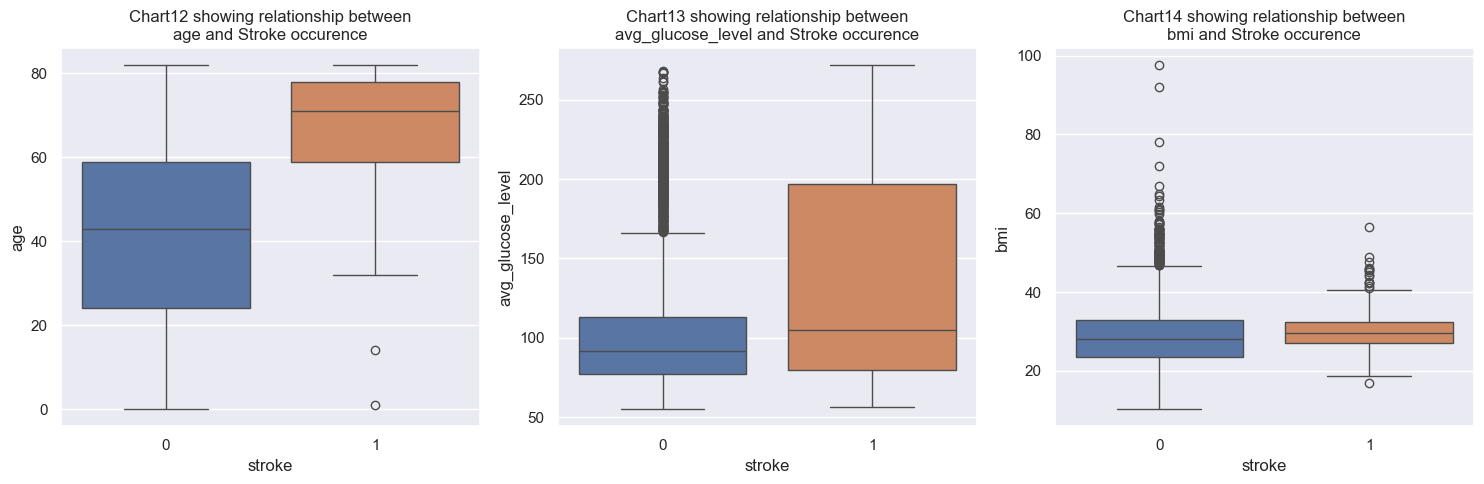

In [30]:
# a. Relationship between "stroke" occurence and numerical features (age, bmi and average glucose level)
num_features = ["age", "avg_glucose_level", "bmi"] 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, num_c in enumerate(num_features):
    sns.boxplot(ax=axes[i], x="stroke", y=num_c, data=stroke_dset, hue="stroke", legend=False)
    axes[i].set_title(f"Chart{i+12} showing relationship between\n{num_c} and Stroke occurence")

plt.tight_layout()

plt.show

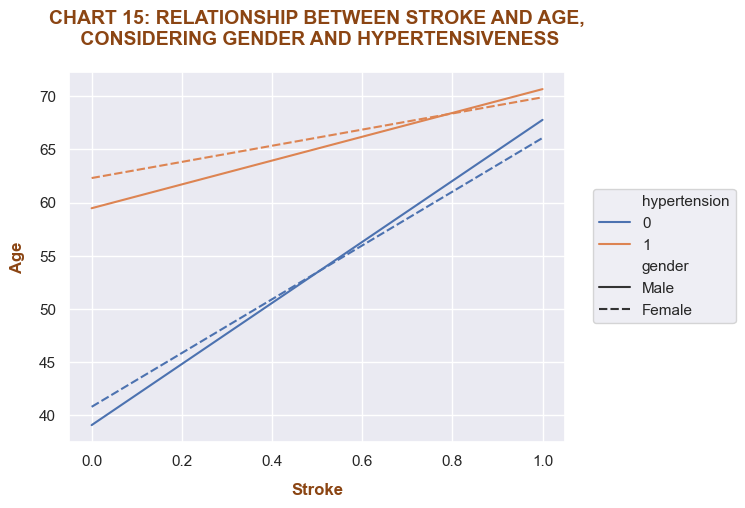

In [31]:
sns.lineplot(data=stroke_dset, x="stroke", y="age", hue="hypertension", style="gender", errorbar=None)
plt.legend(bbox_to_anchor=(1.2, 0.3), loc="lower center")
plt.xlabel("Stroke", labelpad=10, color = "saddlebrown", fontweight="bold")
plt.ylabel("Age", labelpad=10, color = "saddlebrown", fontweight="bold")
plt.title("CHART 15: RELATIONSHIP BETWEEN STROKE AND AGE,\n CONSIDERING GENDER AND HYPERTENSIVENESS", pad=20, color = "saddlebrown", fontweight = "bold", fontsize= 14)

plt.show()

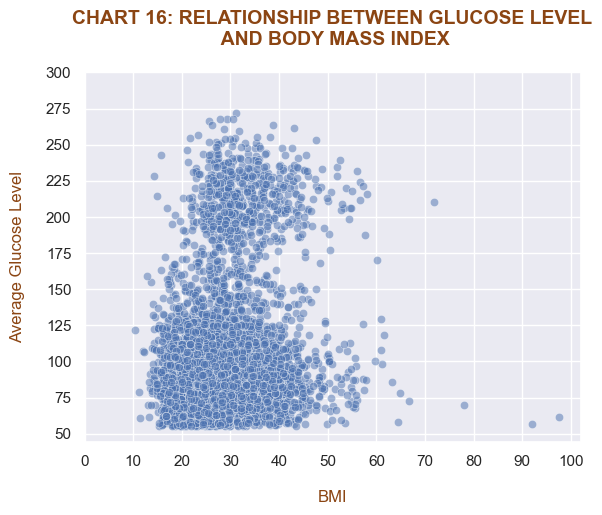

In [32]:
sns.scatterplot(x= stroke_dset["bmi"], y=stroke_dset["avg_glucose_level"], alpha=0.5)
plt.xlabel("BMI", labelpad=15, color = "saddlebrown")
plt.ylabel("Average Glucose Level", labelpad=15, color = "saddlebrown")
plt.title("CHART 16: RELATIONSHIP BETWEEN GLUCOSE LEVEL\n AND BODY MASS INDEX", pad=20, color = "saddlebrown", fontweight = "bold", fontsize=14)
plt.yticks(range(50, 301, 25))
plt.xticks(range(0, 101, 10))

plt.show()

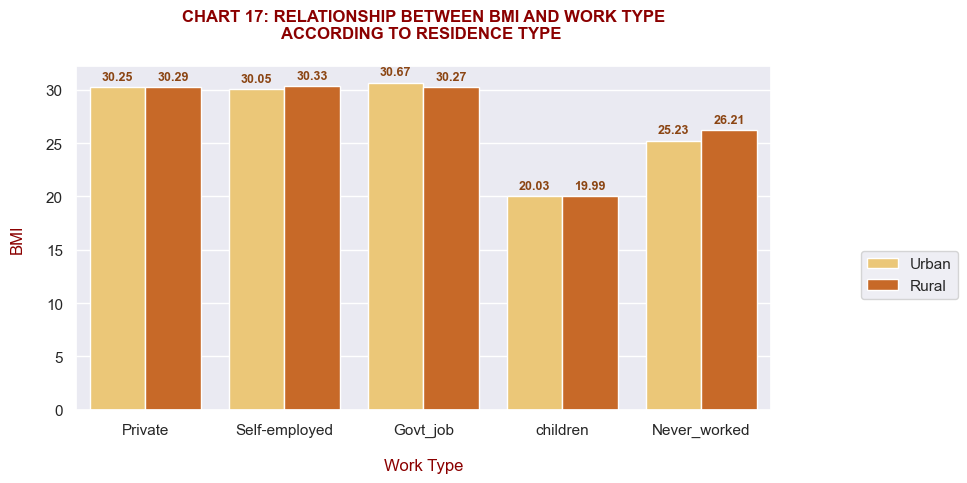

In [33]:
plt.figure(figsize=(10,5)) #make the plot more visible by increasing height and width
bars = sns.barplot(data = stroke_dset, x = "work_type", y="bmi", palette = "YlOrBr", hue= "Residence_type", legend= True, errorbar=None)
plt.title("CHART 17: RELATIONSHIP BETWEEN BMI AND WORK TYPE\nACCORDING TO RESIDENCE TYPE ", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("BMI", labelpad=15, color = "darkred")
plt.xlabel ("Work Type", labelpad=15, color = "darkred")
plt.legend(bbox_to_anchor=(1.2, 0.3), loc="lower center")


plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")

plt.show()

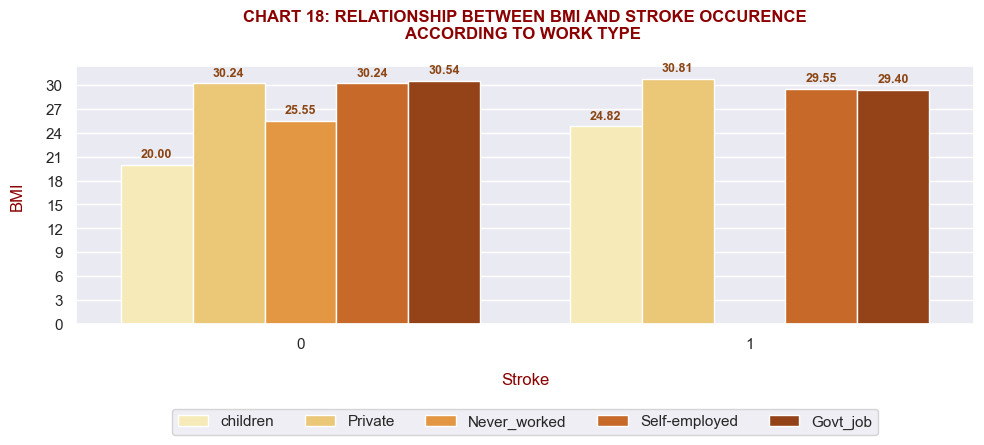

In [34]:
#plt.figure(figsize=(19,8)) #make the plot more visible by increasing height and width
plt.figure(figsize=(10,5))
bars = sns.barplot(data = stroke_dset, x = "stroke", y="bmi", palette = "YlOrBr", hue= "work_type", legend= True, errorbar=None)
plt.title("CHART 18: RELATIONSHIP BETWEEN BMI AND STROKE OCCURENCE\nACCORDING TO WORK TYPE ", pad=20, color = "darkred", fontweight = "bold")
plt.ylabel("BMI", labelpad=15, color = "darkred")
plt.xlabel ("Stroke", labelpad=15, color = "darkred")
plt.yticks(range(0, 31, 3))
plt.legend(ncol=5, bbox_to_anchor=(.5, -0.3), loc="upper center")


plt.tight_layout()
for i in bars.containers:
    bars.bar_label(i, fmt="{:,.2f}", padding=3, fontsize=9, fontweight="bold", color= "saddlebrown")

plt.show()

Key Observations from Charts 12 to 18

**Age Factor**
Age Gap (The Medians): The median age for patients who suffered a stroke is significantly higher than those who did not. This clearly shows a positive correlation between age and stroke occurrence.
The Interquartile Range (The Boxes) shows that most strokes occur within a specific older age bracket, whereas the "No Stroke" group is much more spread out across all ages (including children).
The Lower Outliers: In rare conditions, strokes might still occur in younger-aged individuals and they are therefore not completely free from the risk of coming up with stroke. This is indicated by the dots below the whisker.
Average Glucose Level vs. Stroke

Generally, stroke patients have a higher median than patients with no stroke. individuals with hypertension considerably show higher average age compared to those without hypertension across both genders and both stroke outcomes. the relationship between age and stroke occurence appears similar across subgroups as indicated by the nearly parallel lines in the plot (Chart 15).

Though glucose level is a risk factor for stroke, it is not the definitive cause as many people with high average glucose levels still do not suffer stroke.

**BMI Factor**
From the box plot, the median value for both the stroke and no stroke categories are close though that of the stroke category is slightly higher. This might imply that there is a weak correlation between the body mass index and stroke occurrence.

BMI does not vary condierably  with residence type. ALso the BMI of children is considerably lower while that of those who never worked is slightly lower than others. The BMI for the other categories of work type (government job, self employed and private) are within the same range.

**Hypertension**
A number of patients still came up with stroke without being hypertensive. This shows that, though hypertension is a risk factor for stroke, not having hypertension does not definitely translate to not having stroke. The same can be said of heart disease and smoking.

### MULTIVARIATE ANALYSIS (USING HEATMAP)

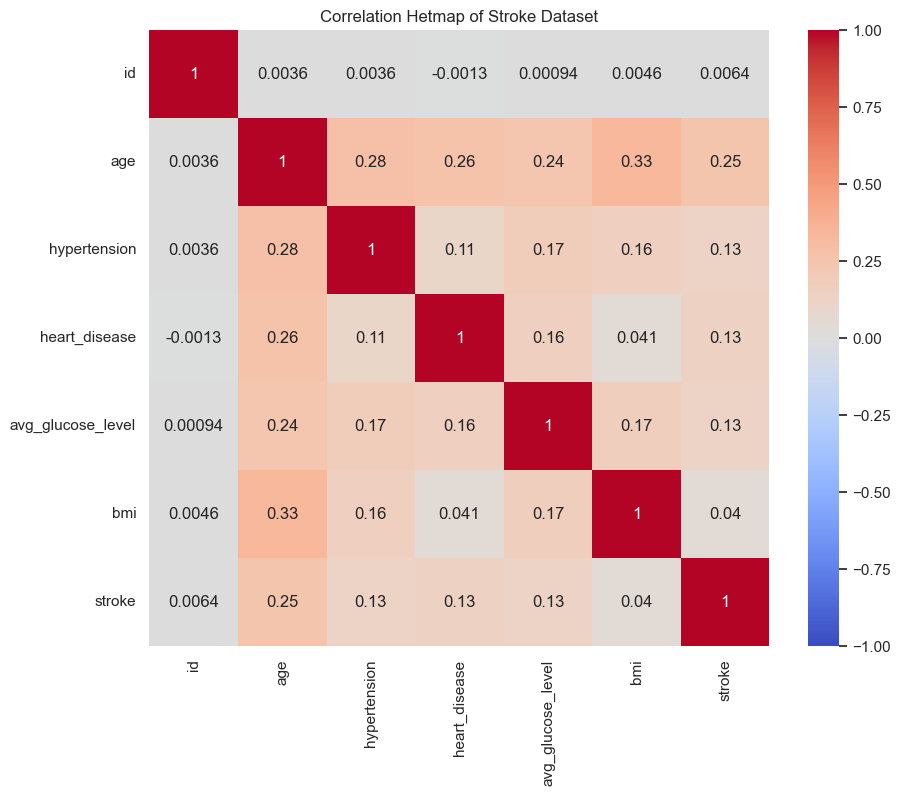

In [35]:
plt.figure(figsize=(10,8))
corr = stroke_dset.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap ='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Hetmap of Stroke Dataset')
plt.show()

Correlation analysis shows age has the strongest positive association with stroke (r ≈ 0.25), indicating that stroke risk tends to increase with age.

However, the relationship is moderate, meaning age alone does not determine stroke occurrence. Hypertension and average glucose show weaker but consistent positive associations.

it also summarizes the correlation between the different numerical features. It highlights "age" and "bmi" are the features with the strongest correlation (0.33).

Multiple analytical methods including correlation analysis, group comparisons, and model interpretability consistently indicate age, hypertension, and glucose as relevant stroke risk indicators.

### PRE-PROCESSING, FEATURE ENGINEERING, ENCODING AND TEST SPLITTING
In order to effectively train database using models, following steps are necessary:

1. drop the Id column as it creates noise in the model building.
2. Seperating data into independent (X) and dependent or target (Y) variables.
3. Encoding to convert object-type information to numbers. This is necessary as prediction models only work with numbers.
4. Feature scaling to transform numerical features to a similar scale or range, preventing features with large magnitudes from disproportionately influencing the model. It primarily ensures that all features contribute equally to the learning process, enhancing model accuracy, speed, and reliability.
5. Train-test-split - splitting database to allow for training and evaluation of Learning Model's performance before deployment.

In [36]:
stroke_dset.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,29.45,never smoked,1
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1


#### FEATURE ENGINEERING

In [37]:
#Dropping the ID column, it is not needed in the model building

stroke_training_set = stroke_dset.drop(columns=["id"])

stroke_training_set

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked,1
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,29.45,never smoked,1
2,Male,80,0,1,Yes,Private,Rural,105.92,32.50,never smoked,1
3,Female,49,0,0,Yes,Private,Urban,171.23,34.40,smokes,1
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.70,never smoked,0
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.00,never smoked,0
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.60,never smoked,0
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.60,formerly smoked,0


In [38]:
# Seperating database to independent (Y) and dependent variables (X)

stroke_X = stroke_training_set.drop(columns=["stroke"])

stroke_X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Male,67,0,1,Yes,Private,Urban,228.69,36.60,formerly smoked
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,29.45,never smoked
2,Male,80,0,1,Yes,Private,Rural,105.92,32.50,never smoked
3,Female,49,0,0,Yes,Private,Urban,171.23,34.40,smokes
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.00,never smoked
...,...,...,...,...,...,...,...,...,...,...
5105,Female,80,1,0,Yes,Private,Urban,83.75,28.70,never smoked
5106,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.00,never smoked
5107,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.60,never smoked
5108,Male,51,0,0,Yes,Private,Rural,166.29,25.60,formerly smoked


In [39]:
stroke_Y = stroke_training_set["stroke"]

stroke_Y

0       1
1       1
2       1
3       1
4       1
       ..
5105    0
5106    0
5107    0
5108    0
5109    0
Name: stroke, Length: 5109, dtype: int64

In [40]:
# Convert features with two categories to binary (gender, ever_married and residence type)
stroke_X["gender"] = stroke_training_set["gender"].map({"Male":1, "Female":0})
stroke_X["ever_married"] = stroke_training_set["ever_married"].map({"Yes":1, "No":0})
stroke_X["Residence_type"] = stroke_training_set["Residence_type"].map({"Urban":1, "Rural":0})

stroke_X

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67,0,1,1,Private,1,228.69,36.60,formerly smoked
1,0,61,0,0,1,Self-employed,0,202.21,29.45,never smoked
2,1,80,0,1,1,Private,0,105.92,32.50,never smoked
3,0,49,0,0,1,Private,1,171.23,34.40,smokes
4,0,79,1,0,1,Self-employed,0,174.12,24.00,never smoked
...,...,...,...,...,...,...,...,...,...,...
5105,0,80,1,0,1,Private,1,83.75,28.70,never smoked
5106,0,81,0,0,1,Self-employed,1,125.20,40.00,never smoked
5107,0,35,0,0,1,Self-employed,0,82.99,30.60,never smoked
5108,1,51,0,0,1,Private,0,166.29,25.60,formerly smoked


#### FEATURE ENCODING

In [41]:
#Separating object-typed categorical columns for encoding
cat_cols = stroke_X.select_dtypes(include=[object])

cat_cols

,work_type,smoking_status
0,Private,formerly smoked
1,Self-employed,never smoked
2,Private,never smoked
3,Private,smokes
4,Self-employed,never smoked
...,...,...
5105,Private,never smoked
5106,Self-employed,never smoked
5107,Self-employed,never smoked
5108,Private,formerly smoked


In [42]:
#Separating object-typed categorical columns for encoding
cat_cols = stroke_X.select_dtypes(include=[object])

cat_cols

,work_type,smoking_status
0,Private,formerly smoked
1,Self-employed,never smoked
2,Private,never smoked
3,Private,smokes
4,Self-employed,never smoked
...,...,...
5105,Private,never smoked
5106,Self-employed,never smoked
5107,Self-employed,never smoked
5108,Private,formerly smoked


In [43]:
#Encoding of the categorical columns
stroke_X_lab = stroke_X.copy()
for col in cat_cols:
    le = LabelEncoder() #create an instance
    stroke_X_lab[col] = le.fit_transform(stroke_X_lab[col]) #transform each categorical column

In [44]:
stroke_X_lab

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67,0,1,1,2,1,228.69,36.60,1
1,0,61,0,0,1,3,0,202.21,29.45,2
2,1,80,0,1,1,2,0,105.92,32.50,2
3,0,49,0,0,1,2,1,171.23,34.40,3
4,0,79,1,0,1,3,0,174.12,24.00,2
...,...,...,...,...,...,...,...,...,...,...
5105,0,80,1,0,1,2,1,83.75,28.70,2
5106,0,81,0,0,1,3,1,125.20,40.00,2
5107,0,35,0,0,1,3,0,82.99,30.60,2
5108,1,51,0,0,1,2,0,166.29,25.60,1


#### FEATURE SCALING

In [45]:
#Feature Scaling
scaler = StandardScaler()
scaler_X = scaler.fit_transform(stroke_X_lab)

scaler_X

array([[ 1.18979109,  1.05075789, -0.32863749, ...,  2.70644995,
         0.99898062, -0.3518194 ],
       [-0.84048369,  0.78565338, -0.32863749, ...,  2.12165168,
         0.0733804 ,  0.58143361],
       [ 1.18979109,  1.62515099, -0.32863749, ..., -0.00486741,
         0.46821686,  0.58143361],
       ...,
       [-0.84048369, -0.36313281, -0.32863749, ..., -0.51126562,
         0.22225316,  0.58143361],
       [ 1.18979109,  0.34381254, -0.32863749, ...,  1.32837547,
        -0.42501972, -0.3518194 ],
       [-0.84048369,  0.03452395, -0.32863749, ..., -0.46069205,
        -0.34734698, -1.28507241]])

<function matplotlib.pyplot.show(close=None, block=None)>

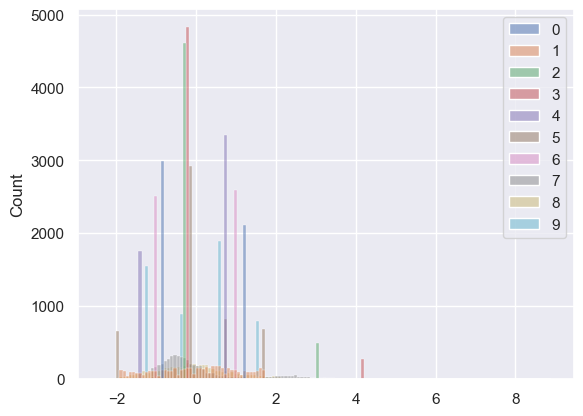

In [46]:
sns.histplot(scaler_X)

plt.show

#### TRAIN - TEST - SPLIT

In [47]:
scaler_X_train, scaler_X_test, stroke_Y_train, stroke_Y_test = train_test_split(scaler_X, stroke_Y, test_size=0.3, stratify=stroke_Y, random_state=3)
#0.2 so that training data can be maximized especially due to the imbalance, ensure model captures enough pattern for reliable prediction, 
#stratify to ensure the randomization of the test set has enough stroke cases.


stroke_Y_test.describe()

count    1533.000000
mean        0.048924
std         0.215779
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stroke, dtype: float64

## BASELINE TRAINING

In [48]:
#1. Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(scaler_X_train, stroke_Y_train)

LogisticRegression()

In [49]:
lr_predict = lr_model.predict(scaler_X_test)
# Check the accuracy score
print(f"The Accuracy score is {accuracy_score(stroke_Y_test, lr_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, lr_predict))

The Accuracy score is 0.95

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533



In [50]:
confusion_matrix(stroke_Y_test, lr_predict)

array([[1457,    1],
       [  75,    0]])

In [51]:
#Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores = cross_val_score(
    lr_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV ROC-AUC:", lr_cv_scores)
print("Mean ROC-AUC:", lr_cv_scores.mean()) 

Logistic Regression CV ROC-AUC: [0.86062513 0.84676514 0.86995798 0.83021008 0.84810924]
Mean ROC-AUC: 0.8511335159614507


The logistic regression model demonstrated strong performance in predicting non-stroke cases by 94% accurancy with a 100% recall and 97% f1 but failed to correctly predict stroke cases. This might be as a result of imbalance data. Stratified 5-fold cross-validation was used to reveal a mean ROC-AUC of 0.85, indicating that the model can still discriminate between stroke and non-stroke instances. To improve predictions for the minority stroke class, techniques like class weighting, threshold tuning, which are part of hyparametertunning

In [52]:
# 2. Decision Tree Classifier
dt_model = DecisionTreeClassifier()

dt_model.fit(scaler_X_train, stroke_Y_train)

DecisionTreeClassifier()

In [53]:
dt_predict = dt_model.predict(scaler_X_test)
print(f"The Accuracy is {accuracy_score(stroke_Y_test, dt_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, dt_predict))

The Accuracy is 0.90

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1458
           1       0.09      0.11      0.10        75

    accuracy                           0.90      1533
   macro avg       0.52      0.52      0.52      1533
weighted avg       0.91      0.90      0.91      1533



In [54]:
confusion_matrix(stroke_Y_test, dt_predict)

array([[1375,   83],
       [  67,    8]])

In [55]:
#Cross Validation
dt_cv_scores = cross_val_score(
    dt_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Decision Tree Classifier CV ROC-AUC:", dt_cv_scores)
print("Mean ROC-AUC:", dt_cv_scores.mean()) 

Decision Tree Classifier CV ROC-AUC: [0.56842878 0.57504103 0.55084034 0.5585084  0.51197479]
Mean ROC-AUC: 0.5529586680487173


The Decision Tree Classifier also demonstrated strong performance in predicting non-stroke cases by 95% accurancy with a 100% recall and 975 f1. it also has a low recall for positive case (0.12). however, a mean ROC-AUC of 0.56 shows that the model has no real predictive power.

In [56]:
#3. Support Vector Machine
svm_model = SVC(random_state=4)
svm_model.fit(scaler_X_train, stroke_Y_train)

SVC(random_state=4)

In [57]:
svm_predict = svm_model.predict(scaler_X_test)

print(f"The Accuracy score is {accuracy_score(stroke_Y_test, svm_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, svm_predict))

The Accuracy score is 0.95

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.00      0.00      0.00        75

    accuracy                           0.95      1533
   macro avg       0.48      0.50      0.49      1533
weighted avg       0.90      0.95      0.93      1533



In [58]:
confusion_matrix(stroke_Y_test, svm_predict)

array([[1458,    0],
       [  75,    0]])

In [59]:
#Cross Validation
svm_cv_scores = cross_val_score(
    svm_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("SVM CV ROC-AUC:", svm_cv_scores)
print("Mean ROC-AUC:", svm_cv_scores.mean()) 

SVM CV ROC-AUC: [0.61833438 0.60792952 0.5697479  0.6697479  0.62105042]
Mean ROC-AUC: 0.6173620232233863


SVM also demonstrated strong performance in predicting non-stroke cases by 95% accurancy with a 100% recall and 97% f1 but has no low recall for positive case (0). A mean ROC-AUC of 0.62 shows that the model has very weak predictive power.

In [60]:
# 4. Random forest Classifier
rf_model = RandomForestClassifier(random_state=6)

rf_model.fit(scaler_X_train, stroke_Y_train)

RandomForestClassifier(random_state=6)

In [61]:
rf_predict = rf_model.predict(scaler_X_test)

print(f"The Accuracy score is {accuracy_score(stroke_Y_test, rf_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, rf_predict))

The Accuracy score is 0.95

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.25      0.01      0.03        75

    accuracy                           0.95      1533
   macro avg       0.60      0.51      0.50      1533
weighted avg       0.92      0.95      0.93      1533



In [62]:
confusion_matrix(stroke_Y_test, rf_predict)

array([[1455,    3],
       [  74,    1]])

In [63]:
#Cross Validation
rf_cv_scores = cross_val_score(
    rf_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Random Forest CV ROC-AUC:", rf_cv_scores)
print("Mean ROC-AUC:", rf_cv_scores.mean()) 

Random Forest CV ROC-AUC: [0.81724355 0.83562235 0.78913866 0.79897059 0.79720588]
Mean ROC-AUC: 0.8076362060242598


The Random Forest model demonstrated strong performance in predicting non-stroke cases by 95% accurancy with a 100% recall and 97% f1 but only predicted 1 out of 75 positive class correctly. Stratified 5-fold cross-validation was used to reveal a mean ROC-AUC of 0.81, indicating that the model can still discriminate between stroke and non-stroke instances. To improve predictions for the minority stroke class, techniques like class weighting, threshold tuning, which are part of hyparametertunning

In [64]:
#5. XGBoost Classifier
xgb_model = XGBClassifier(random_state=7)
xgb_model.fit(scaler_X_train, stroke_Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [65]:
xgb_predict = xgb_model.predict(scaler_X_test)

print(f"The Accuracy score is {accuracy_score(stroke_Y_test, rf_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, xgb_predict))

The Accuracy score is 0.95

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1458
           1       0.17      0.07      0.10        75

    accuracy                           0.94      1533
   macro avg       0.56      0.53      0.53      1533
weighted avg       0.92      0.94      0.93      1533



In [66]:
confusion_matrix(stroke_Y_test, xgb_predict)

array([[1434,   24],
       [  70,    5]])

In [67]:
#Cross Validation
xgb_cv_scores = cross_val_score(
    xgb_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("XGB CV ROC-AUC:", xgb_cv_scores)
print("Mean ROC-AUC:", xgb_cv_scores.mean()) 

XGB CV ROC-AUC: [0.80709041 0.80741988 0.83705882 0.79462185 0.81382353]
Mean ROC-AUC: 0.8120028998383495


The XGBoost model also demonstrated strong performance in predicting non-stroke cases by 98% accurancy with a 100% recall and 97% f1. it also has a low recall for positive case (0.07). however, a mean print(f"The Accuracy score is {accuracy_score(stroke_Y_test, rf_predict):.2f}")
print("\nClassification Report\n")ROC-AUC of 0.812 shows that the model has a strong predictive power.

In [68]:
#6. KNN
knn_model = KNeighborsClassifier()
knn_model.fit(scaler_X_train, stroke_Y_train)

KNeighborsClassifier()

In [69]:
knn_predict = knn_model.predict(scaler_X_test)

print(f"The Accuracy score is {accuracy_score(stroke_Y_test, knn_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, knn_predict))

The Accuracy score is 0.95

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1458
           1       0.25      0.01      0.03        75

    accuracy                           0.95      1533
   macro avg       0.60      0.51      0.50      1533
weighted avg       0.92      0.95      0.93      1533



In [70]:
confusion_matrix(stroke_Y_test, knn_predict)

array([[1455,    3],
       [  74,    1]])

In [71]:
#Cross Validation
knn_cv_scores = cross_val_score(
    knn_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("KNeighbors Classifier CV ROC-AUC:", knn_cv_scores)
print("Mean ROC-AUC:", knn_cv_scores.mean()) 

KNeighbors Classifier CV ROC-AUC: [0.62978813 0.66530621 0.59588235 0.64432773 0.59233193]
Mean ROC-AUC: 0.6255272708202224


The KNeighbors Classifiers also demonstrated strong performance in predicting non-stroke cases by 95% accurancy with a 100% recall and 97% f1 but failed to predict any stroke case correctly. A mean ROC-AUC of 0.62 shows that the model has very weak predictive power.

###
All six Algorithms show similar overall accuracy (~94%), but this metric is misleading due to imbalance.

* Logistic Regression currently has the best ROC-AUC (0.85) → better ability to rank stroke vs non-stroke patients probabilistically.

* Random Forest performs worst for minority class, predicting 0 stroke cases despite high accuracy.

* XGBoost baseline is slightly better than Random Forest, but still fails to reliably detect stroke.

Across all models, majority class (non-stroke) dominates performance, highlighting the critical need for class imbalance strategies (class weighting, threshold tuning, resampling).

## HYPER PARAMETER TUNING

### 1. Hyperparameter Tuning of Logistic Regression model using GridSearchCV

In [72]:
lr_model.get_params(deep=True) #getting hyperparameters for the model

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [73]:
#parameter gridding
param_grid = {
    'C': np.logspace(-4, 4, 10),
    'class_weight':['balanced'],
    'solver':['lbfgs', 'liblinear', 'saga'],
    'penalty':['l1','l2'],
    'max_iter':[100, 500, 1000]
}

In [74]:
#Using the GridSearch to get best parameters for tuning
grid_search = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [75]:
grid_search.fit(scaler_X_train, stroke_Y_train) #fitting into Training dataset

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                         'class_weight': ['balanced'],
                         'max_iter': [100, 500, 1000], 'penalty': ['l1', 'l2'],
                         'solver': ['lbfgs', 'liblinear', 'saga']},
             scoring='roc_auc')

In [76]:
best_model = grid_search.best_estimator_

In [77]:
print("Best Parameters:", grid_search.best_params_)

print("Best ROC AUC:", grid_search.best_score_)


Best Parameters: {'C': np.float64(0.046415888336127774), 'class_weight': 'balanced', 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best ROC AUC: 0.8545694295339281


In [78]:
lrg_predict = best_model.predict(scaler_X_test)

In [79]:
# Check the accuracy score
print(f"The Accuracy score is {accuracy_score(stroke_Y_test, lrg_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, lrg_predict))

The Accuracy score is 0.70

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.69      0.81      1458
           1       0.12      0.79      0.20        75

    accuracy                           0.70      1533
   macro avg       0.55      0.74      0.51      1533
weighted avg       0.94      0.70      0.78      1533



In [80]:
confusion_matrix(stroke_Y_test, lrg_predict)

array([[1011,  447],
       [  16,   59]])

## Insight

After tuning Logistic Regressions with class weighting (balanced) and hyperparameter optimization, the model significantly improved detection of stroke cases. Stroke recall increased to **0.79** (59/75 correctly predicted), which is critical in medical applications. The trade-off is significantly reduced performance on non-stroke cases, reflected in lower recall (0.69). Overall, the tuned model is much more useful clinically than baseline models that ignored minority class detection, despite slightly lower overall accuracy.


In [81]:
#Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lrg_cv_scores = cross_val_score(
    best_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Logistic Regression CV ROC-AUC:", lrg_cv_scores)
print("Mean ROC-AUC:", lrg_cv_scores.mean())
print("Std:", lrg_cv_scores.std())

Logistic Regression CV ROC-AUC: [0.85756241 0.8563963  0.86831933 0.82970588 0.84836134]
Mean ROC-AUC: 0.8520690531719295
Std: 0.012859486588220545


## Insight

After tuning Logistic Regressions with class weighting (balanced) and hyperparameter optimization, the model significantly improved detection of stroke cases. Stroke recall increased to **0.79** (59/75 correctly predicted), which is critical in medical applications. The trade-off is significantly reduced performance on non-stroke cases, reflected in lower recall (0.69). Overall, the tuned model is much more useful clinically than baseline models that ignored minority class detection, despite slightly lower overall accuracy.


* ROC-AUC measures the model’s ability to rank stroke vs non-stroke patients correctly, regardless of class imbalance.

* Mean ROC-AUC ~0.85 → strong discriminative ability. The model can separate stroke and non-stroke patients reasonably well.

* Low standard deviation (~0.0129) → performance is stable across all folds.

* Individual fold variation (0.82–0.86) is moderate → some folds have slightly fewer stroke cases, which explains small differences.

It is important to carry out further operation to increase the precision.

In [82]:
# R PR AUC VALIDATION
pr_auc_scores = cross_val_score(
    best_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print("PR-AUC scores:", pr_auc_scores)
print("Mean PR-AUC:", pr_auc_scores.mean())

PR-AUC scores: [0.20310326 0.33630897 0.18097878 0.1904218  0.23206979]
Mean PR-AUC: 0.22857651894072645


Insights:

* PR-AUC is more informative than ROC-AUC for imbalanced datasets, focusing on the minority class (stroke).

* Mean PR-AUC ~0.228 → still relatively low, which reflects that precision and recall for stroke cases remain limited.

* PR-AUC is sensitive to false positives and false negatives in the minority class.

* Even though stroke recall improved (0.79), precision is low (0.12) → this explains the low PR-AUC.

Interpretation: While the model can rank patients fairly well (ROC-AUC), the absolute predictive power for stroke cases is still challenging, due to extreme class imbalance and limited stroke cases. It is better to try Threshold Optimization using the Precision - Recall curve

##### Precision - Recall Curve for Threshold Optimization

In [83]:
y_score = best_model.predict_proba(scaler_X_test)[:, 1]

In [84]:
precision, recall, thresholds = precision_recall_curve(stroke_Y_test, y_score)

f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
threshold_best  = thresholds[best_idx]

print("Best Threshold", {threshold_best})

Best Threshold {np.float64(0.9135179349545491)}


<function matplotlib.pyplot.show(close=None, block=None)>

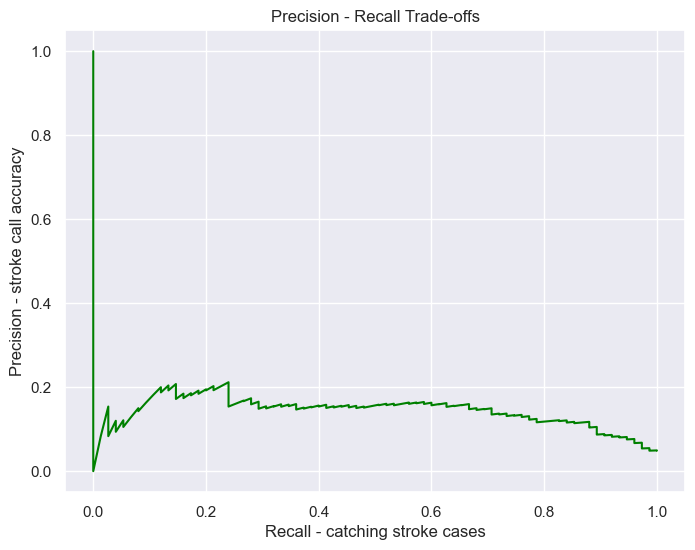

In [85]:
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label= "precision-recall curve", color="green")
plt.xlabel("Recall - catching stroke cases")
plt.ylabel("Precision - stroke call accuracy")
plt.title("Precision - Recall Trade-offs")
plt.grid(True)

plt.show

Curve shows that precision stays mostly between 0.1 and 0.2 and shows that model can not be significantly polished further.

### 2. Hyperparameter Tuning of Random Forest model using GridSearchCV

In [86]:
rf_model.get_params(deep=True) #getting hyperparameters for the model

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 6,
 'verbose': 0,
 'warm_start': False}

In [87]:
#parameter gridding
param_grid2 = {
    'n_estimators': [100, 200, 300],
    'min_samples_split':[2, 5, 10],
    'class_weight':['balanced', 'balanced_subsample'],
    'max_depth':[5, 10, 20, None]
}

In [88]:
#Using the GridSearch to get best parameters for tuning
grid_search2 = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid2,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [89]:
grid_search2.fit(scaler_X_train, stroke_Y_train) #fitting into Training dataset

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=6), n_jobs=-1,
             param_grid={'class_weight': ['balanced', 'balanced_subsample'],
                         'max_depth': [5, 10, 20, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='f1')

In [90]:
best_rf_model = grid_search2.best_estimator_

In [91]:
print("Best Parameters:", grid_search2.best_params_)

print("Best ROC AUC:", grid_search2.best_score_)


Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
Best ROC AUC: 0.22844811986781033


In [92]:
best_rf_predict = best_rf_model.predict(scaler_X_test)

In [93]:
# Check the accuracy score
print(f"The Accuracy score is {accuracy_score(stroke_Y_test, best_rf_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, best_rf_predict))

The Accuracy score is 0.73

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.72      0.83      1458
           1       0.13      0.79      0.22        75

    accuracy                           0.73      1533
   macro avg       0.56      0.75      0.53      1533
weighted avg       0.94      0.73      0.80      1533



In [94]:
confusion_matrix(stroke_Y_test, best_rf_predict)

array([[1053,  405],
       [  16,   59]])

## Insight

After tuning Random Forest hyperparameter optimization, the model significantly improved detection of stroke cases. Stroke recall increased to **0.79** (59/75 correctly predicted), which is critical in medical applications. The trade-off is significantly reduced performance on non-stroke cases, reflected in lower recall of the negative class(0.72). The precision is howvwer still very low (0.13)

In [95]:
#Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfb_cv_scores = cross_val_score(
    best_rf_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Tuned Random Forest CV ROC-AUC:", rfb_cv_scores)
print("Mean ROC-AUC:", rfb_cv_scores.mean())
print("Std:", rfb_cv_scores.std())

Tuned Random Forest CV ROC-AUC: [0.85584225 0.83592468 0.85605042 0.80689076 0.82978992]
Mean ROC-AUC: 0.8368996038944211
Std: 0.018317241255099124


## Insight

* After tuning Random Forest hyperparameter optimization, the model significantly improved detection of stroke cases. Stroke recall increased to **0.79** (59/75 correctly predicted), which is critical in medical applications. The trade-off is significantly reduced performance on non-stroke cases, reflected in lower recall of the negative class(0.72). The precision is howvwer still very low (0.13)

* ROC-AUC measures the model’s ability to rank stroke vs non-stroke patients correctly, regardless of class imbalance.

* Mean ROC-AUC ~0.836 → strong discriminative ability. The model can separate stroke and non-stroke patients reasonably well.

* Low standard deviation (~0.018) → performance is stable across all folds.

* Individual fold variation (0.80–0.86) is moderate → some folds have slightly fewer stroke cases, which explains small differences.

Interpretation: Look into the possibility of further optimization

In [96]:
# R PR AUC VALIDATION
RFpr_auc_scores = cross_val_score(
    best_rf_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print("PR-AUC scores:", RFpr_auc_scores)
print("Mean PR-AUC:", RFpr_auc_scores.mean())

PR-AUC scores: [0.24384545 0.20001526 0.19479863 0.15162528 0.24296387]
Mean PR-AUC: 0.20664969947937636


Insights:

* PR-AUC is more informative than ROC-AUC for imbalanced datasets, focusing on the minority class (stroke).

* Mean PR-AUC ~0.207 → still relatively low, which reflects that precision and recall for stroke cases remain limited.

* PR-AUC is sensitive to false positives and false negatives in the minority class.

* Even though stroke recall improved (0.79), precision is low (0.13) → this explains the low PR-AUC.

Interpretation: While the model can rank patients fairly well (ROC-AUC), the absolute predictive power for stroke cases is still challenging, due to extreme class imbalance and limited stroke cases. It is better to try Threshold Optimization using the Precision - Recall curve

Precision - Recall Curve for Threshold Optimization

In [97]:
y_score2 = best_rf_model.predict_proba(scaler_X_test)[:, 1]

In [98]:
precision2, recall2, thresholds2 = precision_recall_curve(stroke_Y_test, y_score2)

f1_scores2 = 2 * (precision2 * recall2) / (precision2 + recall2)
best_idx2 = np.argmax(f1_scores2)
threshold_best2  = thresholds[best_idx2]

print("Best Threshold", {threshold_best2})

Best Threshold {np.float64(0.802061773912463)}


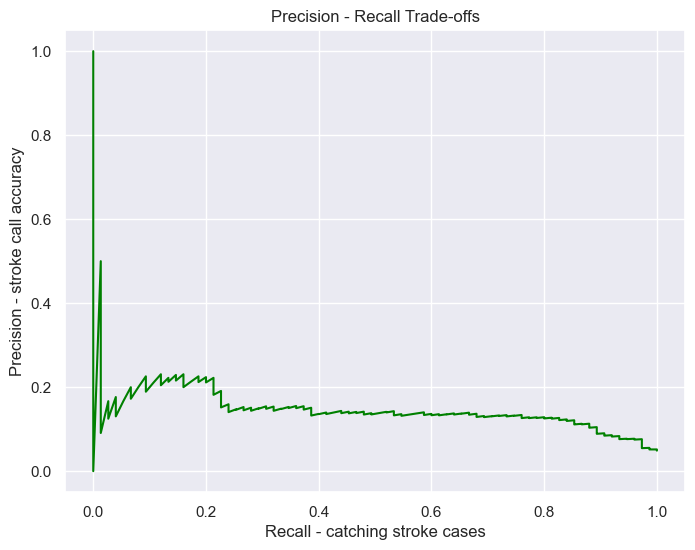

In [99]:
plt.figure(figsize=(8,6))
plt.plot(recall2, precision2, label= "precision-recall curve", color="green")
plt.xlabel("Recall - catching stroke cases")
plt.ylabel("Precision - stroke call accuracy")
plt.title("Precision - Recall Trade-offs")
plt.grid(True)

plt.show()

Curve shows that precision stays mostly between 0.1 and 0.2 and shows that model can not be significantly polished further.

### 3. Hyperparameter Tuning of XGBOOST model using GridSearchCV

In [100]:
xgb_model.get_params(deep=True) #getting hyperparameters for the model

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 7,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [101]:
#parameter gridding
scale_weight = stroke_ir_ratio

param_grid3 = {
    'n_estimators': [100, 200],
    'learning_rate':[0.01, 0.1],
    'scale_pos_weight':[1, scale_weight, scale_weight*2],
    'max_depth':[3, 5, 7]
}

In [102]:
#Using the GridSearch to get best parameters for tuning
grid_search3 = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid3,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [103]:
grid_search3.fit(scaler_X_train, stroke_Y_train) #fitting into Training dataset

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200],
                         'scale_pos_weight': [1, np.float64(19.518072289156628),
                                              np.float64(39.036144578313255)]},
             scoring='f1')

In [104]:
best_xgb_model = grid_search3.best_estimator_

In [105]:
print("Best Parameters:", grid_search3.best_params_)

print("Best ROC AUC:", grid_search3.best_score_)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'scale_pos_weight': np.float64(19.518072289156628)}
Best ROC AUC: 0.23779786946468645


In [106]:
best_xgb_predict = best_xgb_model.predict(scaler_X_test)

In [107]:
# Check the accuracy score
print(f"The Accuracy score is {accuracy_score(stroke_Y_test, best_xgb_predict):.2f}")
print("\nClassification Report\n")
print(classification_report(stroke_Y_test, best_xgb_predict))

The Accuracy score is 0.81

Classification Report

              precision    recall  f1-score   support

           0       0.97      0.82      0.89      1458
           1       0.14      0.57      0.23        75

    accuracy                           0.81      1533
   macro avg       0.56      0.70      0.56      1533
weighted avg       0.93      0.81      0.86      1533



In [108]:
confusion_matrix(stroke_Y_test, best_xgb_predict)

array([[1201,  257],
       [  32,   43]])

## Insight

After tuning XGB hyperparameter optimization, the model significantly improved detection of stroke cases. Stroke recall increased to **0.57** (43/75 correctly predicted), which is still low in medical applications. The trade-off is significantly reduced performance on non-stroke cases, reflected in lower recall of the negative class(0.82). 

In [109]:
#Cross Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb2_cv_scores = cross_val_score(
    best_xgb_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("Tuned XGB CV ROC-AUC:", rfb_cv_scores)
print("Mean ROC-AUC:", xgb2_cv_scores.mean())
print("Std:", xgb2_cv_scores.std())

Tuned XGB CV ROC-AUC: [0.85584225 0.83592468 0.85605042 0.80689076 0.82978992]
Mean ROC-AUC: 0.8178549834030528
Std: 0.024895794956161264


Insights:

* ROC-AUC measures the model’s ability to rank stroke vs non-stroke patients correctly, regardless of class imbalance.

* Mean ROC-AUC ~0.817 → strong discriminative ability. The model can separate stroke and non-stroke patients reasonably well.

* Low standard deviation (~0.024) → performance is stable across all folds.

* Individual fold variation (0.80–0.86) is moderate → some folds have slightly fewer stroke cases, which explains small differences.

Interpretation: The tuned Logistic Regression model is robust and reliable in ranking patients by r

In [110]:
# R PR AUC VALIDATION
XGpr_auc_scores = cross_val_score(
    best_xgb_model,
    scaler_X_train,
    stroke_Y_train,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print("PR-AUC scores:", XGpr_auc_scores)
print("Mean PR-AUC:", XGpr_auc_scores.mean())

PR-AUC scores: [0.19927408 0.17830675 0.233993   0.13113922 0.15273537]
Mean PR-AUC: 0.17908968392795077


Insights:

* PR-AUC is more informative than ROC-AUC for imbalanced datasets, focusing on the minority class (stroke).

* Mean PR-AUC ~0.17 → still relatively low, which reflects that precision and recall for stroke cases remain limited.

* PR-AUC is sensitive to false positives and false negatives in the minority class.

* Even though stroke recall improved (0.57), precision is low (0.14) → this explains the low PR-AUC.

Interpretation: While the model can rank patients fairly well (ROC-AUC), the absolute predictive power for stroke cases is still challenging, due to extreme class imbalance and limited stroke cases. It is better to try Threshold Optimization using the Precision - Recall curve

Precision - Recall Curve for Threshold Optimization

In [111]:
y_score3 = best_xgb_model.predict_proba(scaler_X_test)[:, 1]

In [112]:
precision3, recall3, thresholds3 = precision_recall_curve(stroke_Y_test, y_score3)

f1_scores3 = 2 * (precision3 * recall3) / (precision3 + recall3)
best_idx3 = np.argmax(f1_scores3)
threshold_best3  = thresholds[best_idx3]

print("Best Threshold", {threshold_best3})

Best Threshold {np.float64(0.8937333632168684)}


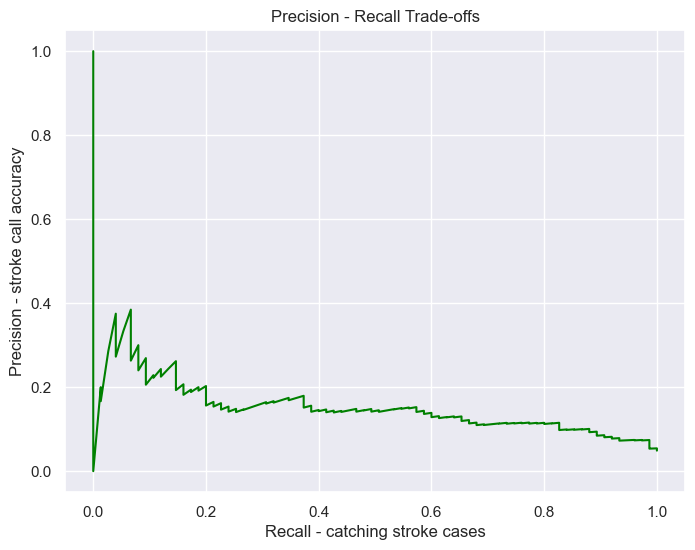

In [113]:
plt.figure(figsize=(8,6))
plt.plot(recall3, precision3, label= "precision-recall curve", color="green")
plt.xlabel("Recall - catching stroke cases")
plt.ylabel("Precision - stroke call accuracy")
plt.title("Precision - Recall Trade-offs")
plt.grid(True)

plt.show()

Curve shows that precision stays mostly between 0.1 and 0.2 and shows that model can not be significantly polished further.

### Conclusion

From the three Models (XG Boost, Random Forest and Logistic Regression) hyperparameter tuned, it can be concludede that, there is no way optimization of the precision and recall is possible. applying SMOTE  makes the output unreliable for real-life use especially as it applies to health Cases.
The performance of the models after hyperparameter tuning are as follows:

XGB - Mean PR - AUC - 0.179, standard dev - 0.025, Mean ROC - AUC -0.817, Standard dev = 0.249, recall (+) - 0.57, precision(+) 0.14, accuracy score -0.81

Random Forest - Mean PR-AUC - 0.207, std - 0.183, mean ROC-AUC- 0.837, precision(+) - 0.13, recall(+) - 0.79, accuracy score is 0.73

Logistic Regression - Mean PR-AUC - 0.228, std - 0.129, mean ROC-AUC - 0.85, precision(+) - 0.12, recall(+) - 0.79, accuracy score is 0.70




### Recommendations

From the analysis and training carried out on dataset, the followings are recommended:

+ Early interventions should focus on managing modifiable risk factors as identified in EDA e.g hypertension, smoking, bmi and average glucose level. This can be achieved by screening people at high risk due to the risk factors e.g aged people, people with hypertension etc.
+ Campaign to modify behaviour and lufestyle should be embarked on especially on demographies at high risk e.g smokers, obese individuals etc
+ Additional lifestyle and health records, which are also proven as strong risk factors for stroke, should be obtained for patient e.g Alcohol intake, exposure to illicit drugs and dietary information.
+ Ensuring enough positive cases, especially for a medical case so rampant, should be given priority. This ensures that Learning models get enough information to train on.

### Some Ethical Consideration in Medical Risk Prediction
1. Bias - Models trained on skewed samples or data might not perform well generally e.g model trained on class imbalance to "No stroke" might find it difficult to correctly identify stroke. Also samples taken in Europe or America might fail in Asia or Africa.
2. Privacy - Ensuring confidentiality of health data is very important especially when sharing data to train Models.
3. Accountability: The question of who takes the blame between the programmer, developer and the medical personell still lingers in cases where model predicts wrongly.
